In [ ]:
# Run this once
!pip install -q \
    transformers==4.48.0 \
    datasets==3.2.0 \
    accelerate==1.3.0 \
    evaluate==0.4.3 \
    rouge-score==0.1.2 \
    sentencepiece==0.2.0 \
    nltk==3.9.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.9.0 w

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Standard System & Data Handling
import os
import torch
import numpy as np
import nltk

# 2. Cloud Storage Integration
from google.colab import drive

# 3. Essential Hugging Face Libraries
import transformers
import datasets
import evaluate
import accelerate

# 4. Specific Model & Training Classes
# We use Seq2Seq versions to support predict_with_generate
from transformers import (
    PegasusTokenizer,
    PegasusForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments, # Added for generation support
    Seq2SeqTrainer             # Added for generation support
)

# 5. Initialization
nltk.download("punkt", quiet=True)

True

In [ ]:
nltk.download("punkt_tab", quiet=True)

True

In [ ]:
print(f"Transformers: {transformers.__version__}") # Should be 4.48.0
print(f"Accelerate: {accelerate.__version__}")     # Should be 1.3.0
print(f"GPU Active: {torch.cuda.is_available()}") # Should be True

Transformers: 4.48.0
Accelerate: 1.3.0
GPU Active: True


In [ ]:
print(torch.cuda.get_device_name(0))

Tesla T4


In [ ]:
#load data set
dataset = datasets.load_dataset("cnn_dailymail", "3.0.0")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

In [ ]:
#phase 1 subset
train_data = dataset["train"].shuffle(seed=42).select(range(10000))
val_data = dataset["validation"].shuffle(seed=42).select(range(1000))
print(train_data)
print(val_data)

Dataset({
    features: ['article', 'highlights', 'id'],
    num_rows: 10000
})
Dataset({
    features: ['article', 'highlights', 'id'],
    num_rows: 1000
})


In [ ]:
# 1. Define model name
model_name = "google/pegasus-arxiv"

# 2. Load tokenizer and model
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name)

# 3. Handle device placement
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)


# 4. adding this to prevent 'Out of Memory' errors on  Tesla T4
model.gradient_checkpointing_enable()

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-arxiv and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [ ]:
# Check if the model is on the GPU (cuda)
print(f"Model location: {next(model.parameters()).device}")

Model location: cuda:0


In [ ]:
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128

def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["article"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=examples["highlights"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [ ]:

# 1. Apply the preprocessing to your Phase 1 subsets
tokenized_train = train_data.map(
    preprocess_function,
    batched=True,
    remove_columns=train_data.column_names
)

tokenized_val = val_data.map(
    preprocess_function,
    batched=True,
    remove_columns=val_data.column_names
)

# 2. Final Verification
print(f"Tokenized samples: {len(tokenized_train)}")
print(f"Features: {tokenized_train.column_names}")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenized samples: 10000
Features: ['input_ids', 'attention_mask', 'labels']


In [ ]:
#data collator
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)


In [ ]:
#ROUGE evaluation function

In [ ]:
import nltk
import evaluate

# 1. Load the metric globally (for normal runs)
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    # 2. Safety Load: If 'rouge' becomes undefined due to a session reset,
    # this re-imports it so the trainer doesn't crash at Step 500 again.
    try:
        metric = rouge
    except NameError:
        import evaluate
        metric = evaluate.load("rouge")

    predictions, labels = eval_pred

    # Decode the predictions and labels
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # Replace -100 in labels (they are not decodable)
    labels = [[(l if l != -100 else tokenizer.pad_token_id) for l in label]
              for label in labels]
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Add Newline characters (Critical for ROUGE-L)
    decoded_preds = ["\n".join(nltk.sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(nltk.sent_tokenize(label.strip())) for label in decoded_labels]

    # Compute results
    result = metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    # Scale by 100 for 0-100 readability
    return {
        "rouge1": round(result["rouge1"] * 100, 4),
        "rouge2": round(result["rouge2"] * 100, 4),
        "rougeL": round(result["rougeL"] * 100, 4)
    }

In [ ]:
#set training arguments
# Create the directory
output_dir = "/content/drive/MyDrive/phase2"
os.makedirs(output_dir, exist_ok=True)

# Use Seq2SeqTrainingArguments
training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="steps",
    predict_with_generate=True,     # Critical for ROUGE
    generation_max_length=128,      # Critical for ROUGE

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,  # Effective Batch Size = 8

    learning_rate=1e-5,
    num_train_epochs=3,

    fp16=True,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",

    logging_steps=100,
    eval_steps=700,
    save_steps=700,
    save_total_limit=2,             # Keeps Drive from filling up

    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    report_to="none"
)

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

In [ ]:
import os
import nltk

# 1. Automatic Resume Logic
resume_from_checkpoint = None
if os.path.exists(output_dir):
    # Check if there are any checkpoint folders in the directory
    checkpoints = [f for f in os.listdir(output_dir) if f.startswith("checkpoint-")]
    if checkpoints:
        resume_from_checkpoint = True
        print("Checkpoint found! Resuming Phase 2 training...")
    else:
        print("No checkpoint found. Starting fresh Phase 2 training...")

# Ensure punkt_tab is downloaded for NLTK sentence tokenization
nltk.download('punkt_tab', quiet=True)

# 2. Start Training
trainer.train(resume_from_checkpoint=resume_from_checkpoint)

# 3. Save the final Phase 1 model
trainer.save_model(f"{output_dir}/final_model_phase2")
print("Phase 2 complete and model saved.")

Checkpoint found! Resuming Phase 2 training...


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
2800,4.505100,4.127153,31.912200,11.808400,22.162600
3500,4.582200,4.109966,31.905200,11.722000,22.019800


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:2758: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 256, 'min_length': 32, 'num_beams': 8, 'length_penalty': 0.8}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Phase 2 complete and model saved.


In [ ]:
print("Best checkpoint path:", trainer.state.best_model_checkpoint)
print("Best ROUGE-L score:", trainer.state.best_metric)


Best checkpoint path: /content/drive/MyDrive/phase2/checkpoint-2100
Best ROUGE-L score: 22.231


In [ ]:
final_model_dir = "/content/drive/MyDrive/phase2_final"

trainer.save_model(final_model_dir)        # saves BEST model (because load_best_model_at_end=True)
tokenizer.save_pretrained(final_model_dir) # saves tokenizer files

print("Best Phase 2 model and tokenizer saved in news_lank folder.")


Best Phase 2 model and tokenizer saved in news_lank folder.


In [ ]:
print(trainer.state.best_model_checkpoint)

/content/drive/MyDrive/phase2/checkpoint-2100


   steps  train_loss  val_loss   ROUGE1   ROUGE2  ROUGE-L
0    700      5.0905  4.447670  30.6612  10.4383  20.9149
1   1400      4.7574  4.260633  31.6379  11.4086  21.8030
2   2100      4.6207  4.173616  31.8150  11.6951  22.2310
3   2800      4.5051  4.127153  31.9122  11.8084  22.1626
4   3500      4.5822  4.109966  31.9052  11.7220  22.0198


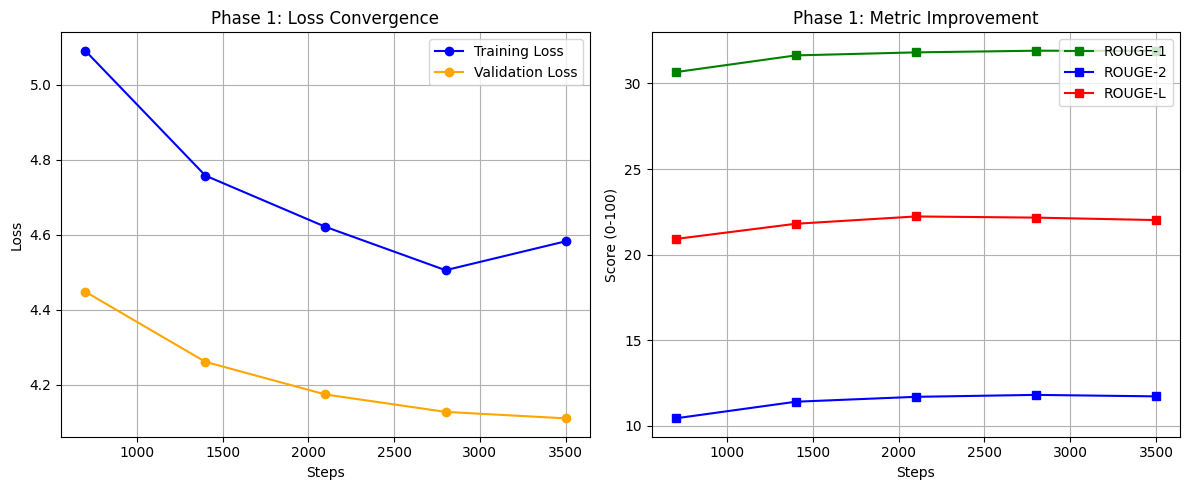

In [ ]:
#plot the training and ROUGE performance
import matplotlib.pyplot as plt

# 1. Extract data from the trainer's memory
history = trainer.state.log_history

steps = []
train_loss = []
val_loss = []
rouge1 = []
rouge2=[]
rougeL = []

for entry in history:
    if 'eval_loss' in entry: # This picks up our 500, 1000, 1500, 2000, 2500 steps
        steps.append(entry['step'])
        val_loss.append(entry['eval_loss'])
        rouge1.append(entry['eval_rouge1'])
        rouge2.append(entry['eval_rouge2'])
        rougeL.append(entry['eval_rougeL'])
    elif 'loss' in entry and entry['step'] in [700,1400,2100,2800,3500,3750]:
        train_loss.append(entry['loss'])


import pandas as pd
df=pd.DataFrame({'steps':steps,'train_loss':train_loss,'val_loss':val_loss,'ROUGE1':rouge1,'ROUGE2':rouge2,'ROUGE-L':rougeL})
print(df)

# 2. Create the Plot
plt.figure(figsize=(12, 5))

# Subplot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(steps, train_loss, label='Training Loss', marker='o', color='blue')
plt.plot(steps, val_loss, label='Validation Loss', marker='o', color='orange')
plt.title('Phase 1: Loss Convergence')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: ROUGE Improvement
plt.subplot(1, 2, 2)
plt.plot(steps, rouge1, label='ROUGE-1', marker='s', color='green')
plt.plot(steps, rouge2, label='ROUGE-2', marker='s', color='blue')
plt.plot(steps, rougeL, label='ROUGE-L', marker='s', color='red')
plt.title('Phase 1: Metric Improvement')
plt.xlabel('Steps')
plt.ylabel('Score (0-100)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from transformers import PegasusForConditionalGeneration, PegasusTokenizer
import torch


In [ ]:
#best checkpoint was checkpoint 1500 as it provided peak rougeL
model_path = "/content/drive/MyDrive/phase2_final"
model = PegasusForConditionalGeneration.from_pretrained(model_path)
tokenizer = PegasusTokenizer.from_pretrained(model_path)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

PegasusForConditionalGeneration(
  (model): PegasusModel(
    (shared): Embedding(96103, 1024, padding_idx=0)
    (encoder): PegasusEncoder(
      (embed_tokens): Embedding(96103, 1024, padding_idx=0)
      (embed_positions): PegasusSinusoidalPositionalEmbedding(1024, 1024)
      (layers): ModuleList(
        (0-15): 16 x PegasusEncoderLayer(
          (self_attn): PegasusAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (final_layer_no

In [ ]:
def generate_summary_test(text):
    # 1. Prepare the input text (Tokenization)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=512
    ).to(device) # Ensure it uses the same GPU as the model

    # 2. Generate the Summary using your specific Phase 1 parameters
    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=256,      # Match your training config
        min_length=70,       # Ensures at least 3-4 sentences
        num_beams=8,         # High quality beam search
        length_penalty=0.8,  # Balances detail vs brevity
        early_stopping=True
    )

    # 3. Decode back to readable text
    decoded_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return decoded_summary

# --- RUN THE TEST ---
article = """
Finance Minister Nirmala Sitharaman Sunday announced a full exemption from basic customs duty on 17 life-saving drugs including cancer drugs. She also included seven additional rare diseases that will now qualify for duty-free personal imports of medicines, drugs, and Foods for Special Medical Purpose (FSMP).

Presenting her 9th straight budget, Sitharaman said the government wanted to ease the financial burden on families that depend on imported drugs. “To provide relief to patients, particularly those suffering from cancer, I propose to exempt basic customs duty on 17 drugs or medicines,” she said.

The 17 cancer drugs are: Ribociclib, Abemaciclib, Talycabtagene autoleucel, Tremelimumab, Venetoclax, Ceritinib, Brigatinib, Darolutamide, Toripalimab, Serplulimab, Tislelizumab, Inotuzumab ozogamicin, Ponatinib, Ibrutinib, Dabrafenib, Trametinib and Ipilimumab.

These are targeted therapies or immunotherapies used in breast cancer, brain tumours and melanoma.

The new list adds to the 36 life-saving drugs and medicines which were fully exempt from basic customs duty in the budget last year. The 2014 list included drugs for rare diseases, other serious chronic illnesses, and three specific cancer drugs, including Trastuzumab Deruxtecan, Osimertinib, and Durvalumab.

Imported cancer drugs in India attract a basic customs duty of 10 percent, while some categories of lifesaving drugs/vaccines attract a concessional rate of 5 percent, which has now been made zero for these drugs.

Cancer is a major and growing public health challenge in India. The disease imposes catastrophic health expenditure in India, with medicines constituting more than 60 percent of out-of-pocket expenditure.

Research has shown wide price variations and limited cost containment for cancer drugs.

Last year, a parliamentary committee asked the government to impose price caps on certain cancer medicines. A Tata Memorial Centre study found that fewer than 3 percent of Indian cancer patients have access to newer, promising treatments.

Dr Kanika Sood Sharma, Director of Radiation Oncology at Dharamshila Narayana Hospital, said that while the exemption could help more patients access newer cancer treatments, especially targeted therapies and immunotherapies, only a small segment of patients would benefit.

Over the last two decades, she said, cancer treatment has changed sharply with the arrival of these drugs.

“In a few malignancies, they have been life-changing,” Sharma said. She said that around 20 years ago, patients with metastatic lung cancer typically survived for nine to eleven months. Even for stage three disease, five-year survival rates were low despite aggressive chemotherapy and radiation. “Many drugs like durvalumab, which came as adjuvant therapy, have increased survival,” she said.

According to Sharma, the main barrier to using these drugs widely has been cost. She said that when customs duty is removed, a few more patients become eligible by virtue of their ability to afford that drug.

Referring to the list of drugs exempted this year, she said that these are not basic medicines, but high-end drugs often used as second- or third-line treatment.

“I do not think it would go to the grassroots level,” she said. “These are mostly tertiary care-based drugs, used in specialised, mostly private settings.”
"""

output = generate_summary_test(article)

print("-" * 30)
print("GENERATED SUMMARY:")
print("-" * 30)
print(output)

------------------------------
GENERATED SUMMARY:
------------------------------
in her 9th straight budget ,haraman announced a full exemption from basic customs duty on 17 life- saving drugs including cancer drugs . also included seven additional rare diseases that will qualify for duty-free personal imports of medicines, drugs and for cancer drugs . the new list adds to the 36 life- saving drugs and medicines which were fully exempt from basic customs duty in the budget last year .


In [ ]:
test_data = dataset["test"].shuffle(seed=42).select(range(1000))
print(test_data)

MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128

def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["article"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=examples["highlights"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_test = test_data.map(
    preprocess_function,
    batched=True,
    remove_columns=val_data.column_names
)

# 2. Final Verification
print(f"Tokenized samples: {len(tokenized_test)}")

Dataset({
    features: ['article', 'highlights', 'id'],
    num_rows: 1000
})


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenized samples: 1000


In [ ]:
#testing phase
#same collator

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)
#same rouge evaluation metrics
import nltk
import evaluate
import evaluate

# Install bert_score if it's not already installed
!pip install bert_score

rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")
bertscore = evaluate.load("bertscore")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Decode generated summaries
    decoded_preds = tokenizer.batch_decode(
        predictions, skip_special_tokens=True
    )

    # Replace -100 with pad_token_id and decode references
    labels = [
        [(token if token != -100 else tokenizer.pad_token_id) for token in label]
        for label in labels
    ]
    decoded_labels = tokenizer.batch_decode(
        labels, skip_special_tokens=True
    )

    # ROUGE
    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    # METEOR
    meteor_result = meteor.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    # BERTScore
    bert_result = bertscore.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        lang="en"
    )

    return {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "meteor": meteor_result["meteor"],
        "bertscore_f1": sum(bert_result["f1"]) / len(bert_result["f1"])
    }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
test_args = Seq2SeqTrainingArguments(
    output_dir="./test_results",
    per_device_eval_batch_size=1,
    predict_with_generate=True,
    generation_max_length=128,
    report_to="none"
)
#initialize test trainer
test_trainer = Seq2SeqTrainer(
    model=model,
    args=test_args,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


/tmp/ipython-input-3009158002.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  test_trainer = Seq2SeqTrainer(


In [ ]:
test_results = test_trainer.evaluate()
print(test_results)